In [1]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import tensorflow as tf

# 1. Reproducibility
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 2. HARDWARE OPTIMIZATION (Based on your 12 Logical Processors)
# Forces TF to use only 1 thread per client model so we can run multiple clients in parallel
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

print("Environment set. TF restricted to 1 thread per instance to allow 12-thread concurrency.")


Environment set. TF restricted to 1 thread per instance to allow 12-thread concurrency.


In [2]:
def load_mnist_data():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = np.expand_dims(x_train.astype(np.float32) / 255.0, axis=-1)
    x_test = np.expand_dims(x_test.astype(np.float32) / 255.0, axis=-1)
    return x_train, y_train, x_test, y_test

def create_iid_partitions(x, y, num_clients):
    indices = np.arange(len(x))
    np.random.shuffle(indices)
    
    samples_per_client = len(x) // num_clients
    partitions = []
    
    for i in range(num_clients):
        start = i * samples_per_client
        end = start + samples_per_client if i != num_clients - 1 else len(x)
        partitions.append((x[indices[start:end]], y[indices[start:end]]))
        
    return partitions

def create_non_iid_partitions(x, y, num_clients):
    # Sort by label to create shards
    sorted_indices = np.argsort(y)
    x_sorted, y_sorted = x[sorted_indices], y[sorted_indices]
    
    # 2 shards per client
    num_shards = 2 * num_clients
    shard_size = len(x) // num_shards
    shard_indices = list(range(num_shards))
    np.random.shuffle(shard_indices)
    
    partitions = []
    for i in range(num_clients):
        s1, s2 = shard_indices[i * 2], shard_indices[i * 2 + 1]
        
        x_client = np.concatenate((x_sorted[s1*shard_size:(s1+1)*shard_size], 
                                   x_sorted[s2*shard_size:(s2+1)*shard_size]), axis=0)
        y_client = np.concatenate((y_sorted[s1*shard_size:(s1+1)*shard_size], 
                                   y_sorted[s2*shard_size:(s2+1)*shard_size]), axis=0)
        
        # Shuffle internally
        internal_idx = np.arange(len(x_client))
        np.random.shuffle(internal_idx)
        partitions.append((x_client[internal_idx], y_client[internal_idx]))
        
    return partitions

In [3]:
def create_cnn_model(learning_rate=0.001):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

In [5]:
def train_client_locally(client_id, client_data, global_weights, epochs, batch_size):
    x_local, y_local = client_data
    num_samples = len(x_local)
    
    # Initialize an entirely unique model instance inside this thread execution context
    model = create_cnn_model()
    model.set_weights(global_weights)
    
    model.fit(x_local, y_local, epochs=epochs, batch_size=batch_size, verbose=0)
    
    local_weights = model.get_weights()
    return local_weights, num_samples

class FederatedServer:
    def __init__(self, x_test, y_test):
        self.global_model = create_cnn_model()
        self.x_test = x_test
        self.y_test = y_test

    def get_global_weights(self):
        return self.global_model.get_weights()

    def set_global_weights(self, weights):
        self.global_model.set_weights(weights)

    def aggregate_weights(self, client_updates):
        start_time = time.time()
        total_samples = sum(num_samples for _, num_samples in client_updates)
        global_weights = self.get_global_weights()
        
        new_weights = [np.zeros_like(w) for w in global_weights]
        
        # Sample-weighted FedAvg aggregation step
        for local_weights, num_samples in client_updates:
            weight_factor = num_samples / total_samples
            for i in range(len(new_weights)):
                new_weights[i] += local_weights[i] * weight_factor
                
        self.set_global_weights(new_weights)
        return time.time() - start_time

    def evaluate_global_model(self):
        loss, accuracy = self.global_model.evaluate(self.x_test, self.y_test, verbose=0)
        return loss, accuracy

In [6]:
def run_simulation(partitions, x_test, y_test, num_clients, rounds, epochs=3):
    server = FederatedServer(x_test, y_test)
    
    # HARDWARE MATCH: Limit to 12 concurrent workers max based on your system
    max_workers = min(num_clients, 12)  
    
    history = {'loss': [], 'acc': [], 'time': []}
    start_sim = time.time()
    
    for r in range(1, rounds + 1):
        r_start = time.time()
        global_weights = server.global_model.get_weights()
        client_updates = []
        
        # Concurrent client training using your logical processors
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [
                executor.submit(train_client_locally, i, partitions[i], global_weights, epochs, 32) 
                for i in range(num_clients)
            ]
            for future in futures:
                client_updates.append(future.result())
                
        # Server actions
        server.aggregate_weights(client_updates)
        loss, acc = server.evaluate()
        
        r_time = time.time() - r_start
        history['loss'].append(loss)
        history['acc'].append(acc)
        history['time'].append(r_time)
        
        print(f"Round {r:02d}/{rounds} | Acc: {acc:.4f} | Loss: {loss:.4f} | Time: {r_time:.1f}s")
        
    print(f"Total Simulation Time: {time.time() - start_sim:.1f}s\n")
    return history

In [7]:
print("Preparing MNIST...")
x_train, y_train, x_test, y_test = load_mnist_data()

CLIENTS = 12 # Matches your hardware thread count perfectly
ROUNDS = 10

print(f"--- RUNNING IID FEDERATED LEARNING ({CLIENTS} Clients) ---")
iid_parts = create_iid_partitions(x_train, y_train, CLIENTS)
iid_history = run_simulation(iid_parts, x_test, y_test, CLIENTS, ROUNDS)

print(f"--- RUNNING NON-IID FEDERATED LEARNING ({CLIENTS} Clients) ---")
non_iid_parts = create_non_iid_partitions(x_train, y_train, CLIENTS)
non_iid_history = run_simulation(non_iid_parts, x_test, y_test, CLIENTS, ROUNDS)

Preparing MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 45s 4us/step
--- RUNNING IID FEDERATED LEARNING (12 Clients) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9745 - loss: 0.0894
Round 01/10 | Acc: 0.9745 | Loss: 0.0894 | Time: 231.5s
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9829 - loss: 0.0506
Round 02/10 | Acc: 0.9829 | Loss: 0.0506 | Time: 211.4s
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9867 - loss: 0.0398
Round 03/10 | Acc: 0.9867 | Loss: 0.0398 | Time: 212.4s
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9886 - loss: 0.0350
Round 04/10 | Acc: 0.9886 | Loss: 0.0350 | Time: 210.2s
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9898 - loss: 0.0317
Round 05/10 | Acc: 0.9898 | Loss: 0.0317 | Time: 212.2s
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9904 - loss: 0.0301
Round 06/10 | Acc: 0.9904 | Loss: 0.0301 | Time: 211.2s
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9908 - loss: 0.0299
Round 07/

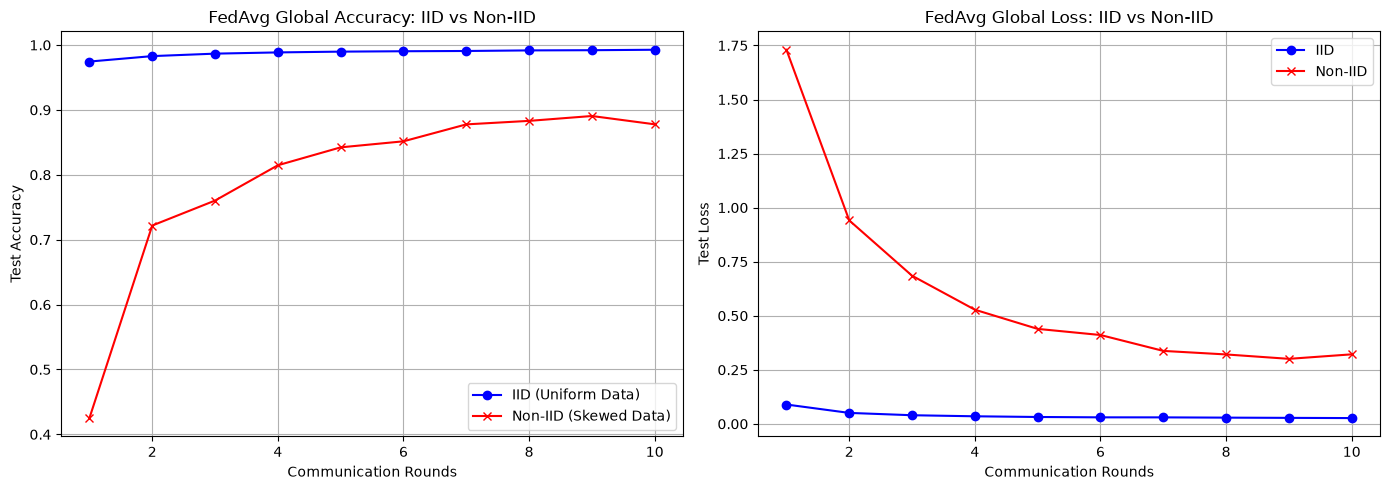

In [8]:
%matplotlib inline

rounds_range = range(1, ROUNDS + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(rounds_range, iid_history['acc'], label='IID (Uniform Data)', marker='o', color='blue')
plt.plot(rounds_range, non_iid_history['acc'], label='Non-IID (Skewed Data)', marker='x', color='red')
plt.title('FedAvg Global Accuracy: IID vs Non-IID')
plt.xlabel('Communication Rounds')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(rounds_range, iid_history['loss'], label='IID', marker='o', color='blue')
plt.plot(rounds_range, non_iid_history['loss'], label='Non-IID', marker='x', color='red')
plt.title('FedAvg Global Loss: IID vs Non-IID')
plt.xlabel('Communication Rounds')
plt.ylabel('Test Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()